# Laboratorio de regresión - 2

## Significancia de factores

|                |                  |
:----------------|------------------|
| **Nombre**     | Omar Mendoza     |
| **Fecha**      | 29/08/2026       |
| **Expediente** | 757806           |

Descarga el archivo de publicidad y carga los datos (Advertising.csv).

In [1]:
# Cargar los datos de publicidad

import pandas as pd

datos = pd.read_csv("Advertising.csv", index_col=0)

print(datos)

        TV  radio  newspaper  sales
1    230.1   37.8       69.2   22.1
2     44.5   39.3       45.1   10.4
3     17.2   45.9       69.3    9.3
4    151.5   41.3       58.5   18.5
5    180.8   10.8       58.4   12.9
..     ...    ...        ...    ...
196   38.2    3.7       13.8    7.6
197   94.2    4.9        8.1    9.7
198  177.0    9.3        6.4   12.8
199  283.6   42.0       66.2   25.5
200  232.1    8.6        8.7   13.4

[200 rows x 4 columns]


In [2]:
datos.shape # Renglones y columnas

(200, 4)

Son 200 renglones y 4 columnas. TV, radio y newspaper son el presupuesto de publicidad
en miles de dólares y sales son las ventas en miles de unidades

**¿Hay alguna relación entre el presupuesto para publicidad y las ventas?**

Nuestra primera meta debe ser determinar si hay evidencia en los datos de que haya una asociación entre estas variables.

- ¿Por qué? ¿Qué resultaría si nos diéramos cuenta de la falta de relación entre el presupuesto de publicidad y las ventas?

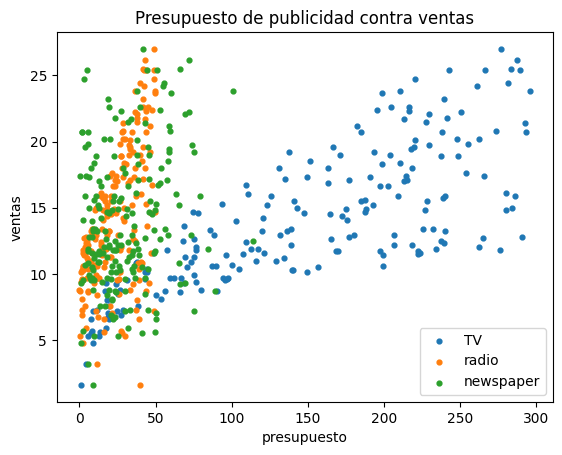

In [3]:
# Gráfica de cada medio contra las ventas

import matplotlib.pyplot as plt

plt.scatter(datos['TV'], datos['sales'], s=12, label='TV')
plt.scatter(datos['radio'], datos['sales'], s=12, label='radio')
plt.scatter(datos['newspaper'], datos['sales'], s=12, label='newspaper')
plt.xlabel('presupuesto')
plt.ylabel('ventas')
plt.title('Presupuesto de publicidad contra ventas')
plt.legend()
plt.show()

- Sí hay relación, en la gráfica se ve que cuando sube el presupuesto también suben las ventas
- Es importante porque el cliente quiere saber en qué gastar su dinero
- Si no hubiera relación, lo que se gasta en publicidad no estaría sirviendo de nada y lo mejor
sería decirle a la empresa que ya no invierta ahí

**¿Qué tan fuerte es esta relación?**
Asumiendo que existe esta relación, ¿nos sirve conocer el impacto que tiene invertir en publicidad en las ventas?

In [4]:
datos.corr()['sales'] # Qué tan relacionado está cada medio con las ventas

TV           0.782224
radio        0.576223
newspaper    0.228299
sales        1.000000
Name: sales, dtype: float64

TV es el que tiene la relación más fuerte con 0.7822, luego radio con 0.5762 y por último
newspaper con 0.2283 que ya es débil

Sí nos sirve conocer el impacto porque así la empresa sabe cuánto le regresa en ventas cada dólar
que mete en cada medio, y puede repartir el presupuesto donde rinde más

**¿Cuáles medios están asociados con las ventas? ¿Qué tan grande es la asociación entre un medio específico y las ventas?**

Hay 3 medios distintos en los datos. ¿Sirve invertir en los 3? ¿Conviene más invertir sólo en uno?

**¿Qué tan seguros estamos de que podríamos predecir ventas futuras?**

**¿La relación es lineal?**

**¿Hay sinergia entre estos medios?**

Puede ser que gastar \\$50,000 en publicidad y otros \\$50,000 en radio es mejor opción que gastar \\$100,000 en televisión. A esto le llamamos efecto de interacción.

Podemos usar regresión lineal para responder todas estas preguntas.

Realiza una regresión lineal:

$$ \text{ventas} \approx \beta_0 + (\beta_1)(\text{TV})$$

In [5]:
import numpy as np
from sklearn.linear_model import LinearRegression

X = np.reshape(datos['TV'].values, (-1, 1))
y = datos['sales'].values

lr = LinearRegression()
lr.fit(X, y)

print("B0:", lr.intercept_)
print("B1:", lr.coef_[0])
print("R2:", lr.score(X, y))

B0: 7.032593549127695
B1: 0.04753664043301975
R2: 0.611875050850071


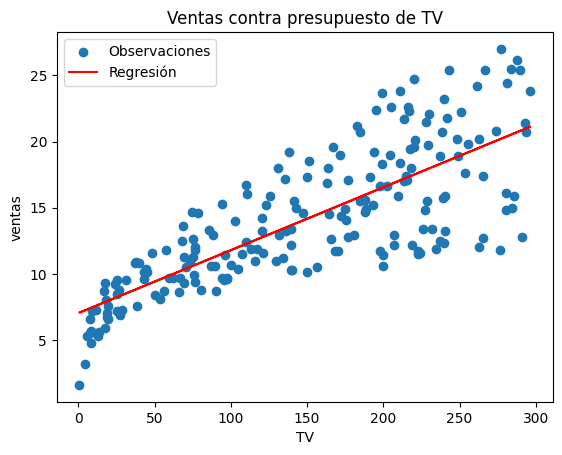

In [6]:
# Los datos con la línea de la regresión

plt.scatter(X, y, label='Observaciones')
plt.plot(X, lr.predict(X), color='red', label='Regresión')
plt.xlabel('TV')
plt.ylabel('ventas')
plt.title('Ventas contra presupuesto de TV')
plt.legend()
plt.show()

Quedan B0 = 7.0326 y B1 = 0.0475, o sea

ventas = 7.0326 + 0.0475 (TV)

El B1 dice que por cada 1000 dólares más que se meten en TV las ventas suben como 47.5 unidades.
El R2 es 0.6119 así que el gasto en TV solo explica el 61 por ciento de lo que varían las ventas

### Verificando la precisión de nuestros coeficientes estimados

Recuerda que en el mundo real hay ruidos y errores de medición. Siempre se asume que la verdadera relación entre $X$ y $Y$ es $$Y = \beta_0 + \beta_1 X + \epsilon$$

Se asume que el término de error es independiente de $X$ (el error siempre es el mismo sin importar el valor de $X$). Este modelo describe a la *línea de regresión de la población*, que es la mejor aproximación de la verdadera relación entre $X$ y $Y$. Cuando usamos mínimos cuadrados encontramos la *línea de mínimos cuadrados*.

¿Cuál es la diferencia entre población y muestra?

La población son todos los casos que existen y la muestra es nada más un pedazo de esa población,
el que sí alcanzamos a medir

Casi nunca se puede medir la población completa por tiempo y dinero, por eso se trabaja con la muestra

¿Cuál crees que sea la diferencia entre hacer una regresión con todos los datos de la población y una muestra de ella?

Con la población completa saldrían los coeficientes verdaderos B0 y B1

Con una muestra nada más salen estimaciones, y si agarráramos otra muestra distinta los números
cambiarían tantito. Por eso los coeficientes traen error estándar, para saber qué tanto se pueden
mover de los verdaderos

La línea de regresión de la población no se puede observar. El concepto de comparar estas líneas es una extensión natural del acercamiento estadístico estándar de usar información de una muestra para estimar características de una población grande.

Imagina que quieres encontrar la altura promedio de un mexicano $\mu$. Medir a todos y cada uno de los mexicanos en situaciones similares, con la misma regla, mismo operador, y otras incontables formas de minimizar la variación de la medida es una tarea imposible. Lo que podemos asumir es que $\hat{\mu} = \bar{y}$. La media poblacional y la media muestral son diferentes, pero la media muestral es usualmente un buen estimado.

De la misma manera, como no contamos con el 100% de la información para hacer una regresión, los coeficientes $\beta_0$ y $\beta_1$ son desconocidos. Podemos estimarlos usando mínimos cuadrados, encontrando $\hat{\beta_0}$ y $\hat{\beta_1}$. Puede que las muestras que tengamos en ese momento estén un poco por encima de la media, pero otras muestras en otro momento puede que estén debajo de la media. En general, esperamos que el promedio de las aproximaciones $\hat{\mu}$ aproxime a $\mu$.

Esto lleva a la pregunta: ¿qué tan cercanos son nuestros coeficientes estimados a los verdaderos coeficientes? Utilizamos el concepto de error estándar para evaluar esto.

$$ \text{Var}(\hat{\mu})=\text{SE}(\hat{\mu})^2 = \frac{\sigma^2}{n} $$

Donde $\sigma$ es la desviación estándar de cada una de las observaciones $y_i$ de $Y$. El error estándar nos dice la cantidad promedio que el estimado difiere del valor verdadero. Podemos ver en la fórmula que entre más observaciones tengamos el error se hace más pequeño. Las fórmulas para errores estándar de $\hat{\beta_0}$ y $\hat{\beta_1}$ son:

$$ \text{SE}(\hat{\beta_0})^2 = \sigma^2 [\frac{1}{n} + \frac{\bar{x}^2}{\sum_{i=1}^n (x_i - \bar{x})^2}]$$

$$ \text{SE}(\hat{\beta_1})^2 = \frac{\sigma^2}{\sum_{i=1}^n (x_i - \bar{x})^2}$$

$$ \sigma^2 = \text{Var}(\epsilon) = \text{RSE}^2 = \frac{\text{RSS}}{n-p}$$

Para que estas fórmulas sean validas asumimos que los errores $\epsilon_i$ tienen varianza común $\sigma^2$ y que no están correlacionados.

Calcula los errores estándar de los coeficientes

In [7]:
# Errores estándar con las fórmulas de arriba

n = len(datos)
p = 2 # Los dos parámetros, B0 y B1

x = datos['TV'].values

residuos = y - lr.predict(X)
rss = np.sum(residuos ** 2)
rse = np.sqrt(rss / (n - p))

sxx = np.sum((x - np.mean(x)) ** 2)

se_b0 = np.sqrt(rse ** 2 * (1 / n + np.mean(x) ** 2 / sxx))
se_b1 = np.sqrt(rse ** 2 / sxx)

print("RSE:", rse)
print("SE B0:", se_b0)
print("SE B1:", se_b1)

RSE: 3.2586563686504624
SE B0: 0.4578429402734785
SE B1: 0.0026906071877968707


SE(B0) = 0.4578 y SE(B1) = 0.0027

Los dos errores salen chicos comparados con los coeficientes, sobre todo el de B1, entonces
las estimaciones son confiables

Estos errores se pueden usar para calcular intervalos de confianza. Un intervalo de confianza del $95\%$ se define como un rango de valores en el cuál se encuentra el desconocido valor verdadero con un $95\%$ de probabilidad.

Otra forma de verlo es que si tomamos muestras repetidas y construimos un intervalo de confianza para cada una, el $95\%$ de los intervalos creados van a contener el valor verdadero. Para la regresión el intervalo de confianza del $95\%$ toma la forma:

$$ \hat{\beta_j} \pm 2\text{SE}(\hat{\beta_j})$$

Calcula los intervalos de confianza para los coeficientes estimados:

In [8]:
# Intervalos de confianza al 95 por ciento

print("B0: [", lr.intercept_ - 2 * se_b0, ",", lr.intercept_ + 2 * se_b0, "]")
print("B1: [", lr.coef_[0] - 2 * se_b1, ",", lr.coef_[0] + 2 * se_b1, "]")

B0: [ 6.116907668580738 , 7.948279429674652 ]
B1: [ 0.04215542605742601 , 0.05291785480861349 ]


B0 queda entre 6.1169 y 7.9483, y B1 entre 0.0422 y 0.0529

Ninguno de los dos intervalos pasa por el cero. Quiere decir que sin publicidad se venden entre
6116 y 7948 unidades, y que por cada 1000 dólares en TV las ventas suben entre 42 y 53 unidades

Los errores estándar también se usan para realizar pruebas de hipótesis. La prueba de hipótesis más común es probar la hipótesis nula de:

$$ H_0: \text{No hay relación entre } X \text{ y } Y \ \ \ \ (\beta_1=0)$$

contra la hipótesis alternativa:
$$ H_0: \text{Hay alguna relación entre } X \text{ y } Y \ \ \ (\beta_1 \neq 0)$$

Explica con tus palabras el significado de la hipótesis nula y la hipótesis alternativa.

La hipótesis nula dice que no pasa nada, que B1 es cero y que el presupuesto de TV no mueve
las ventas

La alternativa dice lo contrario, que B1 no es cero y que sí hay relación entre las dos variables

Se empieza suponiendo que la nula es cierta y solo se rechaza si los datos dan pruebas suficientes

Para probal la hipótesis nula debemos determinar si nuestro estimado $\hat{\beta_1}$ de $\beta_1$ está lo suficientemente alejado de cero para que podamos decir con confianza que este valor no es cero. 

¿Qué tan lejos? Depende de qué tanta confianza tengamos en el estimado encontrado. Si nuestro error estándar es pequeño y nuestro estimado está alejado de cero podríamos decir que hay muy poca probabilidad de que el valor verdadero sea 0. En cambio, si nuestro error estándar es grande y nuestro estimado está muy cerca de cero, entonces podrías ser que el valor verdadero sea cero y que no haya relación entre las variables.

Se calcula un *estadístico t* dado por
$$ t = \frac{\hat{\beta_j} - \mu}{\text{SE}(\hat{\beta_j})} $$

donde $\mu$ es el valor contra el que queremos probar.

Calcula el estadístico t para tus coeficientes estimados, usando como referencia la prueba de hipótesis.

In [9]:
# Estadístico t contra mu = 0, que es la hipótesis nula

t_b0 = (lr.intercept_ - 0) / se_b0
t_b1 = (lr.coef_[0] - 0) / se_b1

print("t B0:", t_b0)
print("t B1:", t_b1)

t B0: 15.360275174117547
t B1: 17.667625600875546


t de B0 = 15.36 y t de B1 = 17.67

Los dos están bien lejos del cero. El de B1 quiere decir que el coeficiente está como 17 errores
estándar arriba del cero, sería mucha casualidad que el valor verdadero fuera cero

La distribución t tiene forma de campana y se parece bastante a la distribución normal cuando $n > 30$. Ya sólo es cuestión de calcular la probabilidad de observar cualquier número tal que su valor absoluto sea igual o mayor que el valor absoluto del estadístico t calculado. En otras palabras:
$$ P(|x| \geq |t|) $$

A esta probabilidad la llamamos *p-value*. Un *p-value* pequeño indica que es poco probable que exista por puro azar una relación significativa entre predictor y respuesta, en caso de que no haya una asociación real entre predictor y respuesta. En otras palabras, el *p-value* te dice la probabilidad de que parezca que hay relación cuando no la hay.

Si el *p-value* es pequeño, inferimos que sí hay una asociación entre el predictor y la respuesta, y **rechazamos la hipótesis nula**.
  

¿Qué tan pequeño? Depende de la aplicación. Un valor muy común es del $5\%$.

Utiliza el siguiente código para calcular el *p-value* para tus coeficientes

`from scipy import stats`

`p_bj = 2*(1 - stats.t.cdf(np.abs(t_bj), n-p))`

In [10]:
from scipy import stats

p_b0 = 2 * (1 - stats.t.cdf(np.abs(t_b0), n - p))
p_b1 = 2 * (1 - stats.t.cdf(np.abs(t_b1), n - p))

print("p-value B0:", p_b0)
print("p-value B1:", p_b1)

p-value B0: 0.0
p-value B1: 0.0


Los dos p-values salen 0.0

En realidad no son cero exacto, nada más son tan chiquitos que la computadora ya no alcanza a
guardar los decimales y los deja en cero

¿Se rechaza la hipótesis nula? ¿Qué significa?

Sí se rechaza. Los p-values son mucho menores que 0.05

Significa que casi no hay chance de ver unos datos así si de verdad no hubiera relación, entonces
sí podemos decir que el presupuesto de TV afecta las ventas

Realiza otras dos regresiones. Ya tienes hecha la regresión de ventas dado el gasto en publicidad de TV. Realiza la regresión para gastos en radio y gastos en periódico. Organiza las respuestas para que debajo de esta celda se tenga:
- Título de regresión
- Coeficientes estimados
- Errores estándar de los coeficientes
- Intervalos de confianza
- Estadísticos t
- p-values
- Observaciones

In [11]:
# Una función para no repetir todo lo de arriba en cada medio

def regresion(columna):
    x = datos[columna].values
    X = np.reshape(x, (-1, 1))

    lr = LinearRegression()
    lr.fit(X, y)

    b0 = lr.intercept_
    b1 = lr.coef_[0]

    rss = np.sum((y - lr.predict(X)) ** 2)
    rse = np.sqrt(rss / (n - p))
    sxx = np.sum((x - np.mean(x)) ** 2)

    se_b0 = np.sqrt(rse ** 2 * (1 / n + np.mean(x) ** 2 / sxx))
    se_b1 = np.sqrt(rse ** 2 / sxx)

    t_b0 = b0 / se_b0
    t_b1 = b1 / se_b1

    p_b0 = 2 * (1 - stats.t.cdf(np.abs(t_b0), n - p))
    p_b1 = 2 * (1 - stats.t.cdf(np.abs(t_b1), n - p))

    print("Regresión de ventas con", columna)
    print("Coeficientes:     B0 =", b0, " B1 =", b1)
    print("Errores estándar: B0 =", se_b0, " B1 =", se_b1)
    print("Intervalo B0: [", b0 - 2 * se_b0, ",", b0 + 2 * se_b0, "]")
    print("Intervalo B1: [", b1 - 2 * se_b1, ",", b1 + 2 * se_b1, "]")
    print("Estadístico t:    B0 =", t_b0, " B1 =", t_b1)
    print("p-values:         B0 =", p_b0, " B1 =", p_b1)
    print("R2:", lr.score(X, y))

In [12]:
regresion('radio')

Regresión de ventas con radio
Coeficientes:     B0 = 9.311638095158283  B1 = 0.20249578339243965
Errores estándar: B0 = 0.5629004962718711  B1 = 0.020411306360090635
Intervalo B0: [ 8.185837102614542 , 10.437439087702025 ]
Intervalo B1: [ 0.1616731706722584 , 0.2433183961126209 ]
Estadístico t:    B0 = 16.542245311258217  B1 = 9.920765472824959
p-values:         B0 = 0.0  B1 = 0.0
R2: 0.33203245544529525


In [13]:
regresion('newspaper')

Regresión de ventas con newspaper
Coeficientes:     B0 = 12.35140706927816  B1 = 0.05469309847227336
Errores estándar: B0 = 0.6214201876094345  B1 = 0.01657572187635816
Intervalo B0: [ 11.108566694059292 , 13.594247444497029 ]
Intervalo B1: [ 0.02154165471955704 , 0.08784454222498969 ]
Estadístico t:    B0 = 19.876095620248947  B1 = 3.2995907436334195
p-values:         B0 = 0.0  B1 = 0.0011481958688881466
R2: 0.05212044544430516


**Observaciones**

En radio queda B1 = 0.2025 con p-value de 0.0, sí es significativo. Por cada 1000 dólares en radio
las ventas suben como 202 unidades, o sea que radio pega más fuerte por dólar que TV. Pero su R2 es
0.3320 así que explica menos de la tercera parte de lo que varían las ventas

En newspaper queda B1 = 0.0547 con p-value de 0.00115, también sale significativo con el 5 por ciento
pero es el más flojo de los tres. Su intervalo de confianza va de 0.0215 a 0.0878, bien ancho, y su
R2 es 0.0521, o sea que apenas explica el 5 por ciento

De las tres regresiones simples la mejor es la de TV porque tiene el R2 más alto. Lo raro es que las
tres salen significativas, cosa que cambia más adelante con la regresión múltiple

## Regresión lineal múltiple

En lugar de hacer una regresión para cada factor independiente, quizás se puede extender el modelo para que tenga varios factores dentro:

$$ Y = \beta_0 + \beta_1 X_1 + \beta_2 X_2 + ... + \beta_p X_p + \epsilon $$

Para nuestro ejemplo de publicidad:

$$ \text{sales} = \beta_0 + \beta_1 (\text{TV}) + \beta_2 (\text{radio}) + \beta_3 (\text{newspaper}) + \epsilon $$

Utiliza la librería `statsmodels` para realizar la regresión. Por defecto la librería statsmodels no toma en cuenta el intercepto ($\beta_0$), por lo que se tendrá que agregar una columna de unos de tamaño *n* a la matriz X.

`import statsmodels.api as sm`

`ols = sm.OLS(Y, X)`

`results = ols.fit()`

`results.summary()`

In [14]:
import statsmodels.api as sm

X_multi = datos[['TV', 'radio', 'newspaper']].values
X_multi = sm.add_constant(X_multi) # La columna de unos del intercepto

ols = sm.OLS(y, X_multi)
results = ols.fit()

results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.897
Model:                            OLS   Adj. R-squared:                  0.896
Method:                 Least Squares   F-statistic:                     570.3
Date:                Sat, 29 Aug 2026   Prob (F-statistic):           1.58e-96
Time:                        11:24:49   Log-Likelihood:                -386.18
No. Observations:                 200   AIC:                             780.4
Df Residuals:                     196   BIC:                             793.6
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.9389      0.312      9.422      0.000       2.324       3.554
x1             0.0458      0.001     32.809      0.000       0.043       0.049
x2             0.1885      0.009     21.893      0.000       0.172       0.206
x3            -0.0010      0.006     -0.177      0.860      -0.013       0.011
==============================================================================
Omnibus:                       60.414   Durbin-Watson:                   2.084
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              151.241
Skew:                          -1.327   Prob(JB):                     1.44e-33
Kurtosis:                       6.332   Cond. No.                         454.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

El modelo queda

ventas = 2.9389 + 0.0458 (TV) + 0.1885 (radio) - 0.0010 (newspaper)

donde x1 es TV, x2 es radio y x3 es newspaper

TV y radio tienen p-value de 0.000 y newspaper de 0.860, y hasta le sale coeficiente negativo.
El R2 subió a 0.897 contra el 0.6119 que daba TV solo, entonces juntando los medios se explica
mucho mejor las ventas

¿Qué diferencias puedes observar entre los *p-values* de una regresión múltiple y los encontrados en las regresiones simples? ¿Por qué crees que existen estas diferencias?

In [15]:
datos.corr() # Para ver cómo se relacionan los medios entre ellos

,TV,radio,newspaper,sales
TV,1.000000,0.054809,0.056648,0.782224
radio,0.054809,1.000000,0.354104,0.576223
newspaper,0.056648,0.354104,1.000000,0.228299
sales,0.782224,0.576223,0.228299,1.000000


La diferencia está en newspaper. En la regresión simple salió significativo con p-value de 0.00115
y en la múltiple sube a 0.860, ya no sirve. TV y radio se mantienen significativos en las dos

Esto pasa por la correlación de 0.3541 que hay entre radio y newspaper. Donde se gasta en radio
también se gasta en periódico, entonces en la regresión simple el periódico se lleva el crédito de
las ventas que en realidad estaba haciendo el radio

En la múltiple ya están los tres medios juntos, así que el coeficiente de newspaper mide lo que
aporta el periódico dejando TV y radio fijos, y ahí se ve que por sí solo no aporta nada

## Referencia

James, G., Witten, D., Hastie, T., Tibshirani, R.,, Taylor, J. (2023). An Introduction to Statistical Learning with Applications in Python. Cham: Springer. ISBN: 978-3-031-38746-3

## Addendum

Para calcular los *p-values* de los parámetros sin `statsmodels`:
1. Calcular RSS
2. Calcular RSE
3. `var_beta = np.linalg.inv(X.T @ X) * rse**2` (X con columna de intercepto)
4. `std_beta = np.sqrt(var_beta.diagonal())` El orden de los valores corresponde al orden de los factores en las columnas de la matriz $X$.
5. Calcular *estadístico t*
6. Calcular *p-value*